In [32]:
import sys
from pathlib import Path

data_reupload_path = Path("/Users/mansigoel/Documents/GitHub/Quantum-Machine-Learning-/data-re upload")
sys.path.append(str(data_reupload_path))

import os
import time
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

from models.LSTMAE_pipeline import (
    load_lstm_ae_checkpoint,
    extract_series,
    series_to_Xy,
    extract_latents,
)

In [33]:
project_root = Path("/Users/mansigoel/Documents/GitHub/Quantum-Machine-Learning-")

file_path = project_root / "SPEI_AllScales_Napak - SPEI_AllScales_Napak.csv"

df = pd.read_csv(file_path)

train_end_idx = 434

df_train = df.iloc[:train_end_idx].copy()
df_test = df.iloc[train_end_idx:].copy()

print("df shape", df.shape)
print("df_train shape", df_train.shape)
print("df_test shape:", df_test.shape)



df shape (539, 17)
df_train shape (434, 17)
df_test shape: (105, 17)


In [34]:
best_ae_checkpoint_path = "lstm_ae_tuning_latent6_window20/run_001_lr_0.01_bs_16_latent_6_win_20.pth"

ae_checkpoint = load_lstm_ae_checkpoint(
    checkpoint_path = best_ae_checkpoint_path,
    device = "cpu"
)

best_model = ae_checkpoint["model"]
best_encoder = ae_checkpoint["encoder"]
best_scaler = ae_checkpoint["scaler"]
best_config = ae_checkpoint["config"]

print(best_config)

LSTMAEConfig(value_col=4, window_size=20, latent_dim=6, train_window_end=350, batch_size=16, n_epochs=1500, learning_rate=0.01, dropout_ratio=0.0, scaler_type='fixed_range', scaler_feature_range=(-1.0, 1.0), fixed_min=0.0, fixed_max=400.0, clip_fixed_scaler=False, use_act=False, device='cpu', save_path='lstm_ae_tuning_latent6_window20/run_001_lr_0.01_bs_16_latent_6_win_20.pth', print_every=0)


In [35]:
value_col = best_config.value_col
window_size = best_config.window_size
train_window_end = best_config.train_window_end

train_series = extract_series(df_train, value_col)

train_series_scaled = best_scaler.transform(train_series).astype(np.float32)

X_all, y_all = series_to_Xy(train_series_scaled, window_size)

X_train = X_all[:train_window_end]
y_train = y_all[:train_window_end]

X_val = X_all[train_window_end:]
y_val = y_all[train_window_end:]


print("X_all:", X_all.shape)
print("y_all:", y_all.shape)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_all: (414, 20, 1)
y_all: (414, 1)
X_train: (350, 20, 1)
y_train: (350, 1)
X_val: (64, 20, 1)
y_val: (64, 1)


In [36]:
test_series = extract_series(df_test, value_col)

test_series_scaled = best_scaler.transform(test_series).astype(np.float32)

X_test, y_test = series_to_Xy(test_series_scaled, window_size)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (85, 20, 1)
y_test: (85, 1)


In [37]:
device = "cpu"

z_train = extract_latents(
    model=best_model,
    X=X_train,
    device=device,
)

z_val = extract_latents(
    model=best_model,
    X=X_val,
    device=device,
)

z_test = extract_latents(
    model=best_model,
    X=X_test,
    device=device,
)

print("z_train:", z_train.shape)
print("z_val:", z_val.shape)
print("z_test:", z_test.shape)

z_train: (350, 6)
z_val: (64, 6)
z_test: (85, 6)


In [38]:
X_qnn_train = np.pi * z_train
X_qnn_val = np.pi * z_val
X_qnn_test = np.pi * z_test

y_train = y_train.reshape(-1)
y_val = y_val.reshape(-1)
y_test = y_test.reshape(-1)

print("X_qnn_train:", X_qnn_train.shape)
print("X_qnn_val:", X_qnn_val.shape)
print("X_qnn_test:", X_qnn_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_qnn_train: (350, 6)
X_qnn_val: (64, 6)
X_qnn_test: (85, 6)
y_train: (350,)
y_val: (64,)
y_test: (85,)


In [39]:
X_qnn_train = np.pi * z_train
X_qnn_val = np.pi * z_val
X_qnn_test = np.pi * z_test

y_train = y_train.reshape(-1)
y_val = y_val.reshape(-1)
y_test = y_test.reshape(-1)

print("X_qnn_train:", X_qnn_train.shape)
print("X_qnn_val:", X_qnn_val.shape)
print("X_qnn_test:", X_qnn_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_qnn_train: (350, 6)
X_qnn_val: (64, 6)
X_qnn_test: (85, 6)
y_train: (350,)
y_val: (64,)
y_test: (85,)


In [40]:
n_qubits = X_qnn_train.shape[1]
print("n_qubits:", n_qubits)

n_qubits: 6


In [41]:
print("Train angle min:", X_qnn_train.min())
print("Train angle max:", X_qnn_train.max())
print("Val angle min:", X_qnn_val.min())
print("Val angle max:", X_qnn_val.max())
print("Test angle min:", X_qnn_test.min())
print("Test angle max:", X_qnn_test.max())

print("Train fraction |theta| > pi:", np.mean(np.abs(X_qnn_train.flatten()) > np.pi))
print("Val fraction |theta| > pi:", np.mean(np.abs(X_qnn_val.flatten()) > np.pi))
print("Test fraction |theta| > pi:", np.mean(np.abs(X_qnn_test.flatten()) > np.pi))

Train angle min: -3.1342707
Train angle max: 3.0107117
Val angle min: -3.1263397
Val angle max: 2.80716
Test angle min: -3.1290405
Test angle max: 2.926869
Train fraction |theta| > pi: 0.0
Val fraction |theta| > pi: 0.0
Test fraction |theta| > pi: 0.0


In [42]:
import pennylane as qml

In [43]:
from torch.utils.data import DataLoader, TensorDataset

def make_qnn_loaders(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=16,
):
    X_train_torch = torch.tensor(X_train, dtype=torch.float64)
    y_train_torch = torch.tensor(y_train, dtype=torch.float64)

    X_val_torch = torch.tensor(X_val, dtype=torch.float64)
    y_val_torch = torch.tensor(y_val, dtype=torch.float64)

    X_test_torch = torch.tensor(X_test, dtype=torch.float64)
    y_test_torch = torch.tensor(y_test, dtype=torch.float64)

    train_dataset = TensorDataset(X_train_torch, y_train_torch)
    val_dataset = TensorDataset(X_val_torch, y_val_torch)
    test_dataset = TensorDataset(X_test_torch, y_test_torch)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader, test_loader

In [44]:
qnn_batch_size = 16

train_loader, val_loader, test_loader = make_qnn_loaders(
    X_train=X_qnn_train,
    y_train=y_train,
    X_val=X_qnn_val,
    y_val=y_val,
    X_test=X_qnn_test,
    y_test=y_test,
    batch_size=qnn_batch_size,
)

In [45]:
def create_qnode(
    n_qubits: int,
    n_reupload_layers: int,
    n_ansatz_layers: int = 1,
    device_name: str = "default.qubit",
    diff_method: str = "backprop",
):
    dev = qml.device(device_name, wires=n_qubits)

    def S(angles):
        for i in range(n_qubits):
            qml.RY(angles[i], wires=i)

    def W(theta_block):
        for ansatz_layer in range(n_ansatz_layers):
            for i in range(n_qubits):
                qml.Rot(
                    theta_block[ansatz_layer, i, 0],
                    theta_block[ansatz_layer, i, 1],
                    theta_block[ansatz_layer, i, 2],
                    wires=i,
                )

            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])

            if n_qubits > 2:
                qml.CNOT(wires=[n_qubits - 1, 0])

    @qml.qnode(dev, interface="torch", diff_method=diff_method)
    def circuit(q_params, angles):
        for layer in range(n_reupload_layers):
            S(angles)
            W(q_params[layer])

        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    return circuit

In [46]:
class HybridQNNRegressor(nn.Module):
    def __init__(
        self,
        n_qubits: int,
        n_reupload_layers: int,
        n_ansatz_layers: int = 1,
        device_name: str = "default.qubit",
        diff_method: str = "backprop",
        use_output_tanh: bool = False,
    ):
        super().__init__()

        self.n_qubits = n_qubits
        self.n_reupload_layers = n_reupload_layers
        self.n_ansatz_layers = n_ansatz_layers

        self.circuit = create_qnode(
            n_qubits=n_qubits,
            n_reupload_layers=n_reupload_layers,
            n_ansatz_layers=n_ansatz_layers,
            device_name=device_name,
            diff_method=diff_method,
        )

        self.q_params = nn.Parameter(
            0.01 * torch.randn(
                n_reupload_layers,
                n_ansatz_layers,
                n_qubits,
                3,
                dtype=torch.float64,
            )
        )

        if use_output_tanh:
            self.classical_head = nn.Sequential(
                nn.Linear(n_qubits, 1),
                nn.Tanh(),
            ).double()
        else:
            self.classical_head = nn.Linear(n_qubits, 1).double()

    def forward(self, angles_batch):
        q_outputs = []

        for angles in angles_batch:
            q_out = self.circuit(self.q_params, angles)
            q_out = torch.stack(q_out)
            q_outputs.append(q_out)

        q_outputs = torch.stack(q_outputs)

        y_pred = self.classical_head(q_outputs)

        return y_pred.squeeze(-1)

In [47]:
def train_one_qnn_model(
    model,
    train_loader,
    val_loader,
    n_epochs=200,
    learning_rate=0.005,
    device="cpu",
    print_every=50,
):
    device = torch.device(device)

    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = None

    for epoch in range(n_epochs):
        model.train()
        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            y_pred = model(X_batch)

            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * X_batch.size(0)

        avg_train_loss = total_train_loss / len(train_loader.dataset)

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch)

                loss = criterion(y_pred, y_batch)

                total_val_loss += loss.item() * X_batch.size(0)

        avg_val_loss = total_val_loss / len(val_loader.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        if print_every is not None and print_every > 0:
            if (epoch + 1) % print_every == 0:
                print(
                    f"Epoch [{epoch + 1}/{n_epochs}] "
                    f"Train Loss: {avg_train_loss:.6f} "
                    f"Val Loss: {avg_val_loss:.6f}"
                )

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
    }

    return model, history

In [48]:
def predict_with_model(model, loader, device="cpu"):
    device = torch.device(device)

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            y_pred = model(X_batch)

            preds.append(y_pred.cpu().numpy())
            targets.append(y_batch.cpu().numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    return preds, targets

In [49]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    if np.std(y_true) > 0 and np.std(y_pred) > 0:
        corr = np.corrcoef(y_true, y_pred)[0, 1]
    else:
        corr = np.nan

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "corr": corr,
    }


def evaluate_qnn_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    scaler,
    device="cpu",
):
    y_train_pred_scaled, y_train_true_scaled = predict_with_model(
        model, train_loader, device=device
    )
    y_val_pred_scaled, y_val_true_scaled = predict_with_model(
        model, val_loader, device=device
    )
    y_test_pred_scaled, y_test_true_scaled = predict_with_model(
        model, test_loader, device=device
    )

    train_scaled_metrics = regression_metrics(
        y_train_true_scaled, y_train_pred_scaled
    )
    val_scaled_metrics = regression_metrics(
        y_val_true_scaled, y_val_pred_scaled
    )
    test_scaled_metrics = regression_metrics(
        y_test_true_scaled, y_test_pred_scaled
    )

    y_train_pred_orig = scaler.inverse_transform(
        y_train_pred_scaled.reshape(-1, 1)
    ).reshape(-1)
    y_train_true_orig = scaler.inverse_transform(
        y_train_true_scaled.reshape(-1, 1)
    ).reshape(-1)

    y_val_pred_orig = scaler.inverse_transform(
        y_val_pred_scaled.reshape(-1, 1)
    ).reshape(-1)
    y_val_true_orig = scaler.inverse_transform(
        y_val_true_scaled.reshape(-1, 1)
    ).reshape(-1)

    y_test_pred_orig = scaler.inverse_transform(
        y_test_pred_scaled.reshape(-1, 1)
    ).reshape(-1)
    y_test_true_orig = scaler.inverse_transform(
        y_test_true_scaled.reshape(-1, 1)
    ).reshape(-1)

    train_orig_metrics = regression_metrics(
        y_train_true_orig, y_train_pred_orig
    )
    val_orig_metrics = regression_metrics(
        y_val_true_orig, y_val_pred_orig
    )
    test_orig_metrics = regression_metrics(
        y_test_true_orig, y_test_pred_orig
    )

    return {
        "train_scaled": train_scaled_metrics,
        "val_scaled": val_scaled_metrics,
        "test_scaled": test_scaled_metrics,

        "train_original": train_orig_metrics,
        "val_original": val_orig_metrics,
        "test_original": test_orig_metrics,

        "predictions": {
            "y_train_pred_scaled": y_train_pred_scaled,
            "y_train_true_scaled": y_train_true_scaled,
            "y_val_pred_scaled": y_val_pred_scaled,
            "y_val_true_scaled": y_val_true_scaled,
            "y_test_pred_scaled": y_test_pred_scaled,
            "y_test_true_scaled": y_test_true_scaled,
            "y_train_pred_orig": y_train_pred_orig,
            "y_train_true_orig": y_train_true_orig,
            "y_val_pred_orig": y_val_pred_orig,
            "y_val_true_orig": y_val_true_orig,
            "y_test_pred_orig": y_test_pred_orig,
            "y_test_true_orig": y_test_true_orig,
        },
    }

In [50]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [51]:
depth_list = [1, 2, 3, 4, 5, 6, 7, 8]

qnn_n_epochs = 200
qnn_learning_rate = 0.005
qnn_batch_size = 16
n_ansatz_layers = 1
seed = 42

device_name = "default.qubit"
diff_method = "backprop"
use_output_tanh = True

In [52]:
qnn_results = []
trained_qnn_models = {}

for depth in depth_list:
    print("=" * 80)
    print(f"Training QNN with data reupload depth = {depth}")

    set_seed(seed)

    model = HybridQNNRegressor(
        n_qubits=n_qubits,
        n_reupload_layers=depth,
        n_ansatz_layers=n_ansatz_layers,
        device_name=device_name,
        diff_method=diff_method,
        use_output_tanh=use_output_tanh,
    )

    start_time = time.time()

    model, history = train_one_qnn_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        n_epochs=qnn_n_epochs,
        learning_rate=qnn_learning_rate,
        device="cpu",
        print_every=50,
    )

    elapsed_time = time.time() - start_time

    eval_results = evaluate_qnn_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        scaler=best_scaler,
        device="cpu",
    )

    row = {
        "n_qubits": n_qubits,
        "latent_dim": n_qubits,
        "reupload_depth": depth,
        "n_ansatz_layers": n_ansatz_layers,
        "seed": seed,
        "qnn_epochs": qnn_n_epochs,
        "qnn_learning_rate": qnn_learning_rate,
        "qnn_batch_size": qnn_batch_size,
        "device_name": device_name,
        "diff_method": diff_method,
        "use_output_tanh": use_output_tanh,
        "best_val_loss_scaled": history["best_val_loss"],
        "best_epoch": history["best_epoch"],
        "elapsed_time_sec": elapsed_time,

        "train_rmse_scaled": eval_results["train_scaled"]["rmse"],
        "val_rmse_scaled": eval_results["val_scaled"]["rmse"],
        "test_rmse_scaled": eval_results["test_scaled"]["rmse"],

        "train_mae_scaled": eval_results["train_scaled"]["mae"],
        "val_mae_scaled": eval_results["val_scaled"]["mae"],
        "test_mae_scaled": eval_results["test_scaled"]["mae"],

        "train_corr": eval_results["train_scaled"]["corr"],
        "val_corr": eval_results["val_scaled"]["corr"],
        "test_corr": eval_results["test_scaled"]["corr"],

        "train_rmse_original": eval_results["train_original"]["rmse"],
        "val_rmse_original": eval_results["val_original"]["rmse"],
        "test_rmse_original": eval_results["test_original"]["rmse"],

        "train_mae_original": eval_results["train_original"]["mae"],
        "val_mae_original": eval_results["val_original"]["mae"],
        "test_mae_original": eval_results["test_original"]["mae"],
    }

    qnn_results.append(row)

    trained_qnn_models[depth] = {
        "model": model,
        "history": history,
        "eval_results": eval_results,
    }

    print(f"Depth {depth}")
    print(f"Best val loss scaled: {history['best_val_loss']:.6f}")
    print(f"Val RMSE original:    {row['val_rmse_original']:.4f}")
    print(f"Test RMSE original:   {row['test_rmse_original']:.4f}")
    print(f"Time:                 {elapsed_time:.2f} sec")

Training QNN with data reupload depth = 1
Epoch [50/200] Train Loss: 0.068658 Val Loss: 0.088332
Epoch [100/200] Train Loss: 0.066926 Val Loss: 0.094447
Epoch [150/200] Train Loss: 0.066656 Val Loss: 0.094250
Epoch [200/200] Train Loss: 0.066892 Val Loss: 0.093812
Depth 1
Best val loss scaled: 0.082518
Val RMSE original:    57.4517
Test RMSE original:   54.8257
Time:                 879.44 sec
Training QNN with data reupload depth = 2
Epoch [50/200] Train Loss: 0.046751 Val Loss: 0.077663
Epoch [100/200] Train Loss: 0.044467 Val Loss: 0.083499
Epoch [150/200] Train Loss: 0.043170 Val Loss: 0.085036
Epoch [200/200] Train Loss: 0.041362 Val Loss: 0.083072
Depth 2
Best val loss scaled: 0.072818
Val RMSE original:    53.9695
Test RMSE original:   56.0487
Time:                 5791.33 sec
Training QNN with data reupload depth = 3
Epoch [50/200] Train Loss: 0.045038 Val Loss: 0.075650
Epoch [100/200] Train Loss: 0.039239 Val Loss: 0.078251
Epoch [150/200] Train Loss: 0.037534 Val Loss: 0.082

In [53]:
qnn_results_df = pd.DataFrame(qnn_results)

qnn_results_df

,n_qubits,latent_dim,reupload_depth,n_ansatz_layers,seed,qnn_epochs,qnn_learning_rate,qnn_batch_size,device_name,diff_method,...,test_mae_scaled,train_corr,val_corr,test_corr,train_rmse_original,val_rmse_original,test_rmse_original,train_mae_original,val_mae_original,test_mae_original
0,6,6,1,1,42,200,0.005,16,default.qubit,backprop,...,0.232461,0.550178,0.579142,0.577745,54.788815,57.451729,54.825722,45.343090,45.074585,46.492229
1,6,6,2,1,42,200,0.005,16,default.qubit,backprop,...,0.237333,0.709764,0.632765,0.537001,46.207439,53.969482,56.048714,37.293732,40.859848,47.466618
2,6,6,3,1,42,200,0.005,16,default.qubit,backprop,...,0.234686,0.649540,0.658596,0.558762,50.576393,52.355591,55.487404,41.530083,39.079071,46.937275
3,6,6,4,1,42,200,0.005,16,default.qubit,backprop,...,0.205923,0.835976,0.596110,0.596870,35.812325,56.427410,54.145756,28.413946,40.288116,41.184502
4,6,6,5,1,42,200,0.005,16,default.qubit,backprop,...,0.237978,0.728788,0.677363,0.520858,45.502716,51.073921,56.895512,36.864353,39.691868,47.595524
5,6,6,6,1,42,200,0.005,16,default.qubit,backprop,...,0.213407,0.775043,0.611799,0.634372,42.121548,54.692539,51.470516,34.404747,40.897003,42.681400
6,6,6,7,1,42,200,0.005,16,default.qubit,backprop,...,0.257666,0.704221,0.601262,0.392875,48.254494,55.575245,62.213516,40.345032,44.853073,51.533134
7,6,6,8,1,42,200,0.005,16,default.qubit,backprop,...,0.270055,0.703979,0.414906,0.380204,49.073059,63.033073,63.357365,41.355648,52.173393,54.011036


In [54]:
qnn_results_df[[
    "reupload_depth",
    "best_epoch",
    "best_val_loss_scaled",
    "train_rmse_original",
    "val_rmse_original",
    "test_rmse_original",
    "train_mae_original",
    "val_mae_original",
    "test_mae_original",
    "train_corr",
    "val_corr",
    "test_corr",
    "elapsed_time_sec",
]]

,reupload_depth,best_epoch,best_val_loss_scaled,train_rmse_original,val_rmse_original,test_rmse_original,train_mae_original,val_mae_original,test_mae_original,train_corr,val_corr,test_corr,elapsed_time_sec
0,1,30,0.082518,54.788815,57.451729,54.825722,45.343090,45.074585,46.492229,0.550178,0.579142,0.577745,879.440162
1,2,25,0.072818,46.207439,53.969482,56.048714,37.293732,40.859848,47.466618,0.709764,0.632765,0.537001,5791.330164
2,3,13,0.068528,50.576393,52.355591,55.487404,41.530083,39.079071,46.937275,0.649540,0.658596,0.558762,2399.165918
3,4,199,0.079601,35.812325,56.427410,54.145756,28.413946,40.288116,41.184502,0.835976,0.596110,0.596870,3156.853225
4,5,20,0.065214,45.502716,51.073921,56.895512,36.864353,39.691868,47.595524,0.728788,0.677363,0.520858,3907.310236
5,6,18,0.074782,42.121548,54.692539,51.470516,34.404747,40.897003,42.681400,0.775043,0.611799,0.634372,4680.997733
6,7,9,0.077215,48.254494,55.575245,62.213516,40.345032,44.853073,51.533134,0.704221,0.601262,0.392875,5510.296146
7,8,11,0.099329,49.073059,63.033073,63.357365,41.355648,52.173393,54.011036,0.703979,0.414906,0.380204,5594.824448


In [55]:
save_dir = "qnn_depth_sweep_results"
os.makedirs(save_dir, exist_ok=True)

qnn_results_path = os.path.join(save_dir, "qnn_depth_sweep_latent6_window20.csv")

qnn_results_df.to_csv(qnn_results_path, index=False)

print("Saved:", qnn_results_path)

Saved: qnn_depth_sweep_results/qnn_depth_sweep_latent6_window20.csv


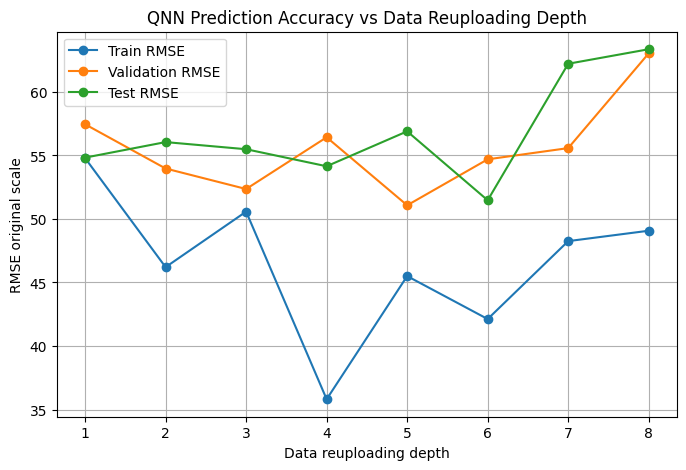

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(
    qnn_results_df["reupload_depth"],
    qnn_results_df["train_rmse_original"],
    marker="o",
    label="Train RMSE",
)
plt.plot(
    qnn_results_df["reupload_depth"],
    qnn_results_df["val_rmse_original"],
    marker="o",
    label="Validation RMSE",
)
plt.plot(
    qnn_results_df["reupload_depth"],
    qnn_results_df["test_rmse_original"],
    marker="o",
    label="Test RMSE",
)

plt.xlabel("Data reuploading depth")
plt.ylabel("RMSE original scale")
plt.title("QNN Prediction Accuracy vs Data Reuploading Depth")
plt.legend()
plt.grid(True)
plt.show()

In [57]:
best_depth = qnn_results_df.sort_values("val_rmse_original").iloc[0]["reupload_depth"]
best_depth = int(best_depth)

print("Best depth by validation RMSE:", best_depth)

Best depth by validation RMSE: 5


In [58]:
best_depth = qnn_results_df.sort_values("val_rmse_original").iloc[0]["reupload_depth"]
best_depth = int(best_depth)

print("Best depth by validation RMSE:", best_depth)

Best depth by validation RMSE: 5


In [59]:
best_depth_results = trained_qnn_models[best_depth]["eval_results"]

y_test_true_orig = best_depth_results["predictions"]["y_test_true_orig"]
y_test_pred_orig = best_depth_results["predictions"]["y_test_pred_orig"]

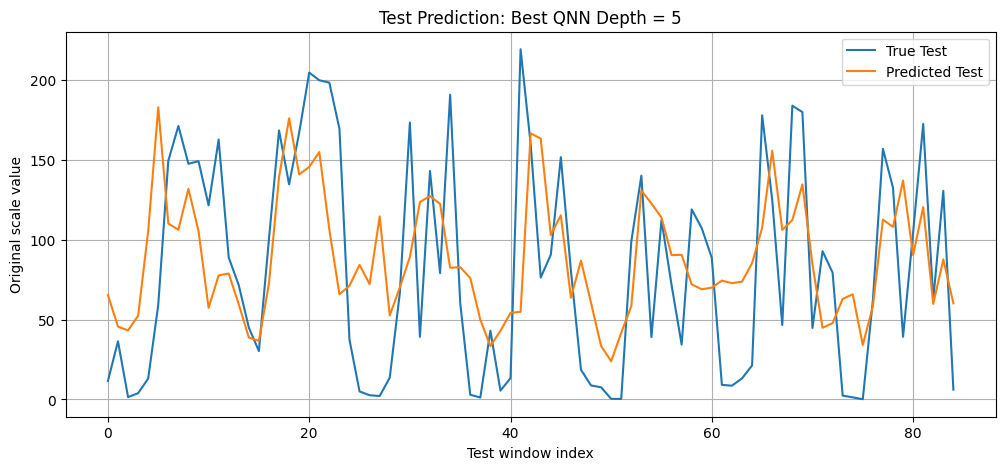

In [60]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_true_orig, label="True Test")
plt.plot(y_test_pred_orig, label="Predicted Test")
plt.xlabel("Test window index")
plt.ylabel("Original scale value")
plt.title(f"Test Prediction: Best QNN Depth = {best_depth}")
plt.legend()
plt.grid(True)
plt.show()